# **Social Media Usage Impact Prediction System using Machine Learning**

### Problem statement

* This project aims to predict the impact of social media usage on individuals’ lifestyle using machine learning based on factors like usage time, age, and behavior. It helps analyze patterns to understand and manage the effects of social media on daily habits and well-being.


### **Importing Data and Required Packages**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#### Import the CSV Data as Pandas DataFrame

In [2]:
data =pd.read_csv("G:\\check\\Social_media_impact_on_life.csv")

#### Show Top 5 Records

In [3]:
data.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative


#### Shape of the data

In [4]:
data.shape

(1705, 11)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    1705 non-null   int64  
 1   Age                           1705 non-null   int64  
 2   Gender                        1705 non-null   object 
 3   Academic_Level                1705 non-null   object 
 4   Country                       1705 non-null   object 
 5   Avg_Daily_Usage_Hours         1705 non-null   float64
 6   Most_Used_Platform            1705 non-null   object 
 7   Affects_Academic_Performance  1705 non-null   object 
 8   Sleep_Hours_Per_Night         1705 non-null   float64
 9   Mental_Health_Score           1705 non-null   float64
 10  Overall_Impact                1705 non-null   object 
dtypes: float64(3), int64(2), object(6)
memory usage: 146.7+ KB


### **Dataset Information**

* Student_ID  -	Unique identifier for each student
* Age - 	Age of the student (in years)
* Gender -	Gender of the student (Male/Female)
* Academic_Level  -	Education level (School / College / University)
* Country -	Country or location of the student
* Avg_Daily_Usage_Hours  -	Average number of hours spent daily on AI/digital platforms
* Most_Used_Platform  -	Platform most frequently used (e.g., ChatGPT, Gemini)
* Affects_Academic_Performance -	Impact of usage on academic performance (Improved / No Change / Decline)
* Sleep_Hours_Per_Night  -	Average sleep duration per night
* Mental_Health_Score  -	Score representing mental well-being
* Overall_Impact  -	Overall effect of usage (Positive / Neutral / Negative)

In [6]:
data.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Overall_Impact                  0
dtype: int64

### Insight
- There are no null values in the dataset

In [7]:
data.duplicated().sum()

np.int64(0)

### Insight
- there are no duplicates in the dataset

In [8]:
data.nunique()

Student_ID                      1000
Age                                7
Gender                             2
Academic_Level                     3
Country                          111
Avg_Daily_Usage_Hours             71
Most_Used_Platform                12
Affects_Academic_Performance       2
Sleep_Hours_Per_Night             59
Mental_Health_Score               51
Overall_Impact                     3
dtype: int64

In [9]:
data.describe()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,1705.000000,1705.000000,1705.000000,1705.000000,1705.000000
mean,439.510264,20.848094,5.103636,6.598710,6.215132
std,267.058174,1.758557,1.677341,1.207045,1.282678
min,1.000000,18.000000,1.500000,3.800000,4.000000
25%,214.000000,19.000000,3.800000,5.600000,5.000000
50%,427.000000,21.000000,5.100000,6.600000,6.000000
75%,640.000000,22.000000,6.300000,7.500000,7.000000
max,1000.000000,24.000000,8.500000,9.600000,9.000000


### Insight
- The min and max values are in good range

### **Exploring Data**

In [10]:
data.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative


In [11]:
print("Categories in 'Gender' variable:     ",end=" " )
print(data['Gender'].unique())

print("Categories in 'Academic_Level' variable:  ",end=" ")
print(data['Academic_Level'].unique())

print("Categories in'Country' variable:",end=" " )
print(data['Country'].unique())

print("Categories in 'Most_Used_Platform' variable:     ",end=" " )
print(data['Most_Used_Platform'].unique())

print("Categories in 'Affects_Academic_Performance' variable:     ",end=" " )
print(data['Affects_Academic_Performance'].unique())

print("Categories in 'Overall_Impact' variable:     ",end=" " )
print(data['Overall_Impact'].unique())

Categories in 'Gender' variable:      ['Male' 'Female']
Categories in 'Academic_Level' variable:   ['Undergraduate' 'Graduate' 'High School']
Categories in'Country' variable: ['Other' 'Canada' 'USA' 'India' 'Australia' 'UK' 'Germany' 'Bangladesh'
 'Brazil' 'Japan' 'South Korea' 'France' 'Spain' 'Italy' 'Mexico' 'Russia'
 'China' 'Sweden' 'Norway' 'Denmark' 'Netherlands' 'Belgium' 'Switzerland'
 'Austria' 'Portugal' 'Greece' 'Ireland' 'New Zealand' 'Singapore'
 'Malaysia' 'Thailand' 'Vietnam' 'Philippines' 'Indonesia' 'Taiwan'
 'Hong Kong' 'Turkey' 'Israel' 'UAE' 'Egypt' 'Morocco' 'South Africa'
 'Nigeria' 'Kenya' 'Ghana' 'Argentina' 'Chile' 'Colombia' 'Peru'
 'Venezuela' 'Ecuador' 'Uruguay' 'Paraguay' 'Bolivia' 'Costa Rica'
 'Panama' 'Jamaica' 'Trinidad' 'Bahamas' 'Iceland' 'Finland' 'Poland'
 'Romania' 'Hungary' 'Czech Republic' 'Slovakia' 'Croatia' 'Serbia'
 'Slovenia' 'Bulgaria' 'Estonia' 'Latvia' 'Lithuania' 'Ukraine' 'Moldova'
 'Belarus' 'Kazakhstan' 'Uzbekistan' 'Kyrgyzstan' 'Taj

### Removing column "Student_ID"

In [12]:
data = data.drop(columns='Student_ID',axis=1)

In [13]:
data.head(2)

,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive


In [14]:
## define numerical and categorical features
numerical_features = data.select_dtypes(include=['int64','float64']).columns
categorical_features = data.select_dtypes(include=['object']).columns
print(numerical_features)
print(categorical_features)

Index(['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score'],
      dtype='object')
Index(['Gender', 'Academic_Level', 'Country', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Overall_Impact'],
      dtype='object')


### **Exploring Data ( Visualization )**

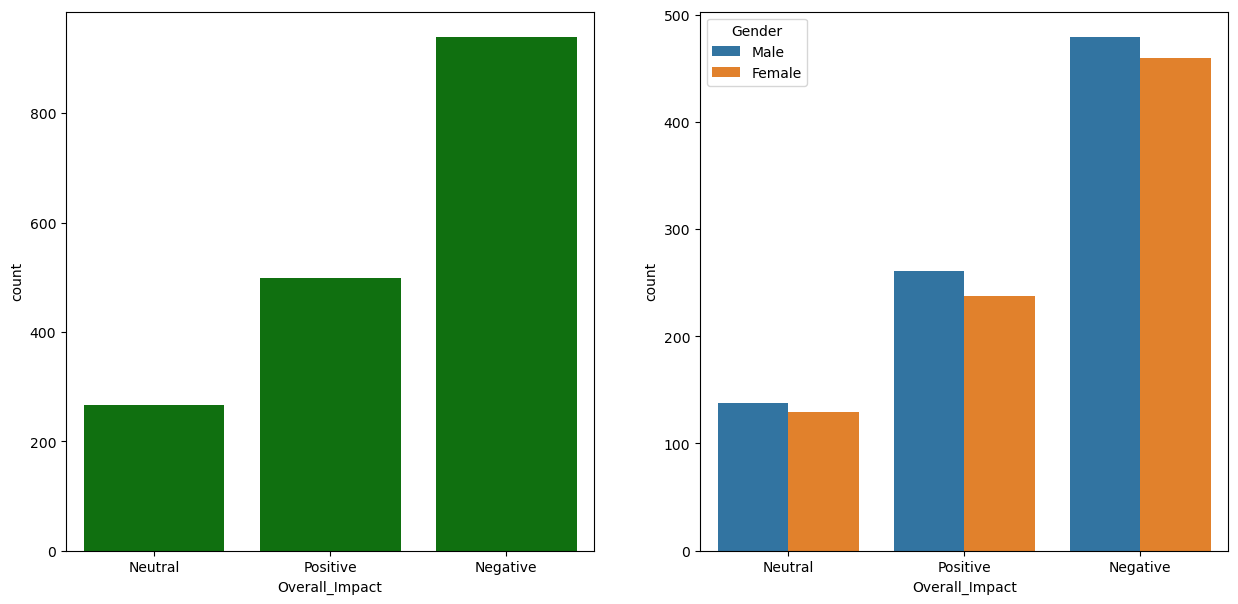

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.countplot(data=data,x='Overall_Impact',color='g')
plt.subplot(122)
sns.countplot(data=data,x='Overall_Impact',hue='Gender')
plt.show()

### Insight
- From plot 1 there are more number of negative
- From plot 2 males are most effected than females 

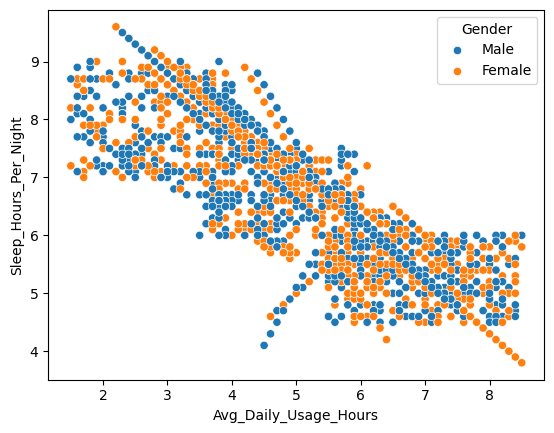

In [16]:
figure = figsize=(15, 7)
sns.scatterplot(data=data,x="Avg_Daily_Usage_Hours",y="Sleep_Hours_Per_Night",hue="Gender",color="b")
plt.show()

### Insights
- From the above plot, it is observed that as sleep hours per night decrease, the average daily social media usage increases. This indicates that individuals who sleep fewer hours tend to spend more time on social media.


### Multivariate analysis using pieplot

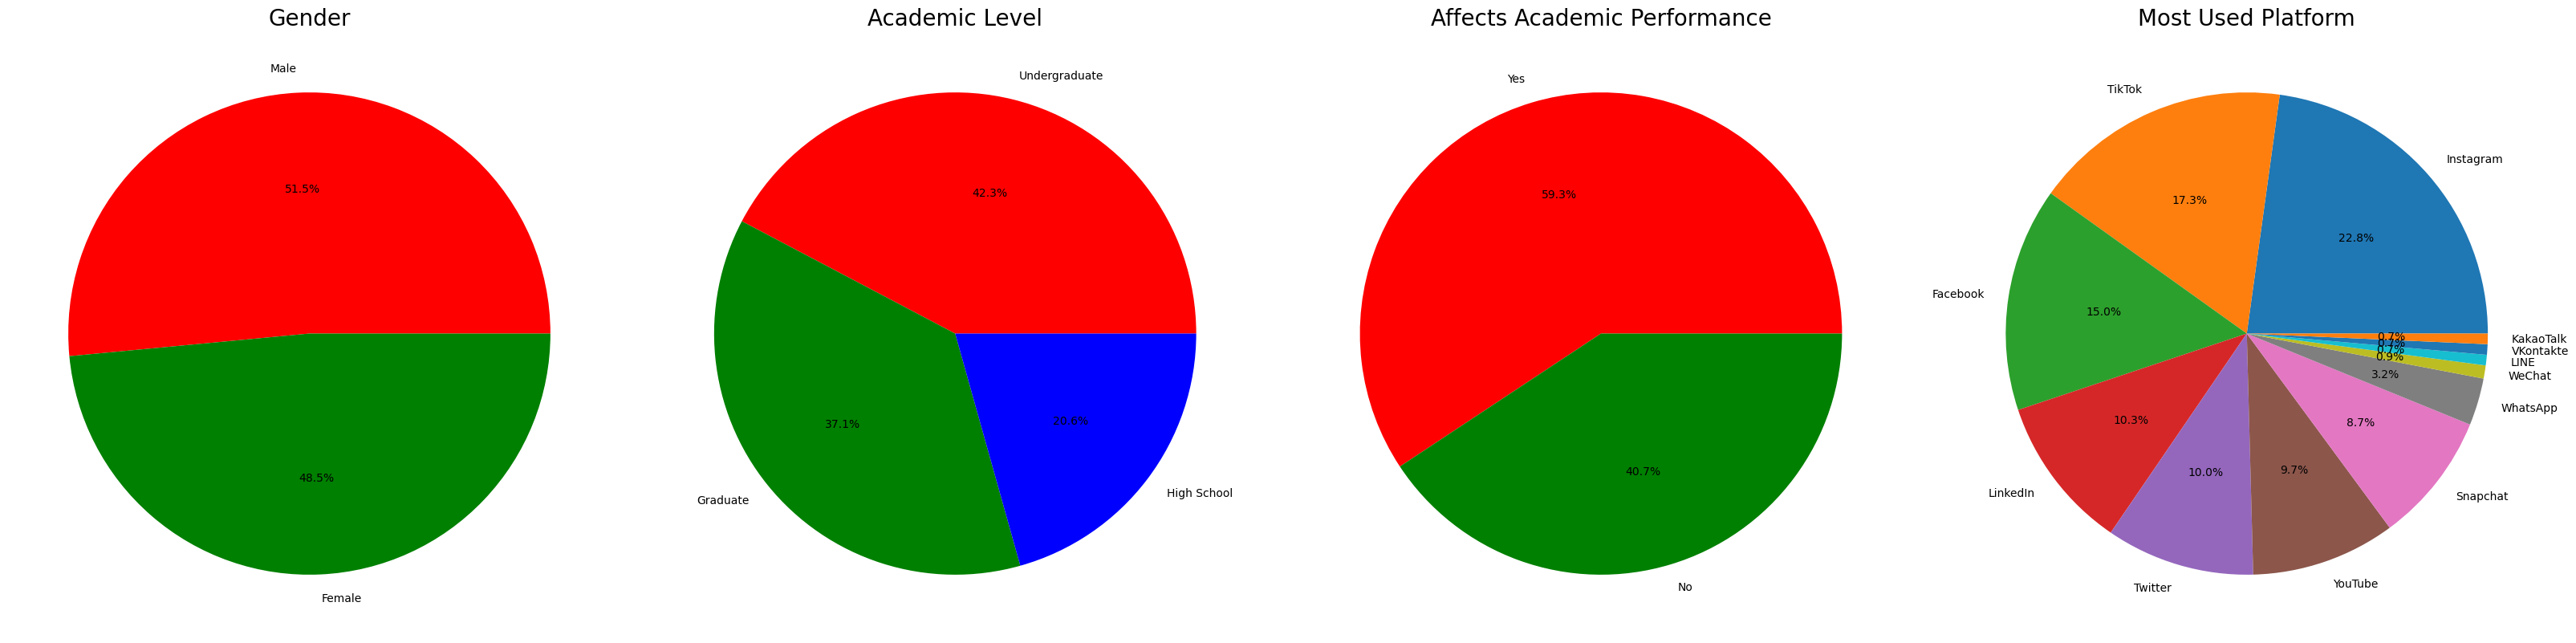

In [17]:
plt.rcParams['figure.figsize'] = (40, 20)

plt.subplot(1, 5, 1)
size = data['Gender'].value_counts()
labels = size.index
colors = ['red', 'green']

plt.pie(size, labels=labels, colors=colors, autopct='%1.1f%%')
plt.title('Gender', fontsize=20)

plt.subplot(1, 5, 2)
size = data['Academic_Level'].value_counts()
labels = size.index
colors = ['red', 'green', 'blue']

plt.pie(size, labels=labels, colors=colors, autopct='%1.1f%%')
plt.title('Academic Level', fontsize=20)


plt.subplot(1, 5, 3)
size = data['Affects_Academic_Performance'].value_counts()
labels = size.index
colors = ['red', 'green']

plt.pie(size, labels=labels, colors=colors, autopct='%1.1f%%')
plt.title('Affects Academic Performance', fontsize=20)


plt.subplot(1, 5, 4)
size = data['Most_Used_Platform'].value_counts()

plt.pie(size, labels=size.index, autopct='%1.1f%%')
plt.title('Most Used Platform', fontsize=20)

plt.tight_layout()
plt.show()

### Insights
* From the first plot, it is observed that the number of male users is higher compared to female users.
* The second plot shows that most individuals belong to the undergraduate academic level.
* From the third plot, a significant number of individuals report that social media usage affects their academic performance.
* The fourth plot indicates that Instagram is the most commonly used social media platform among users.


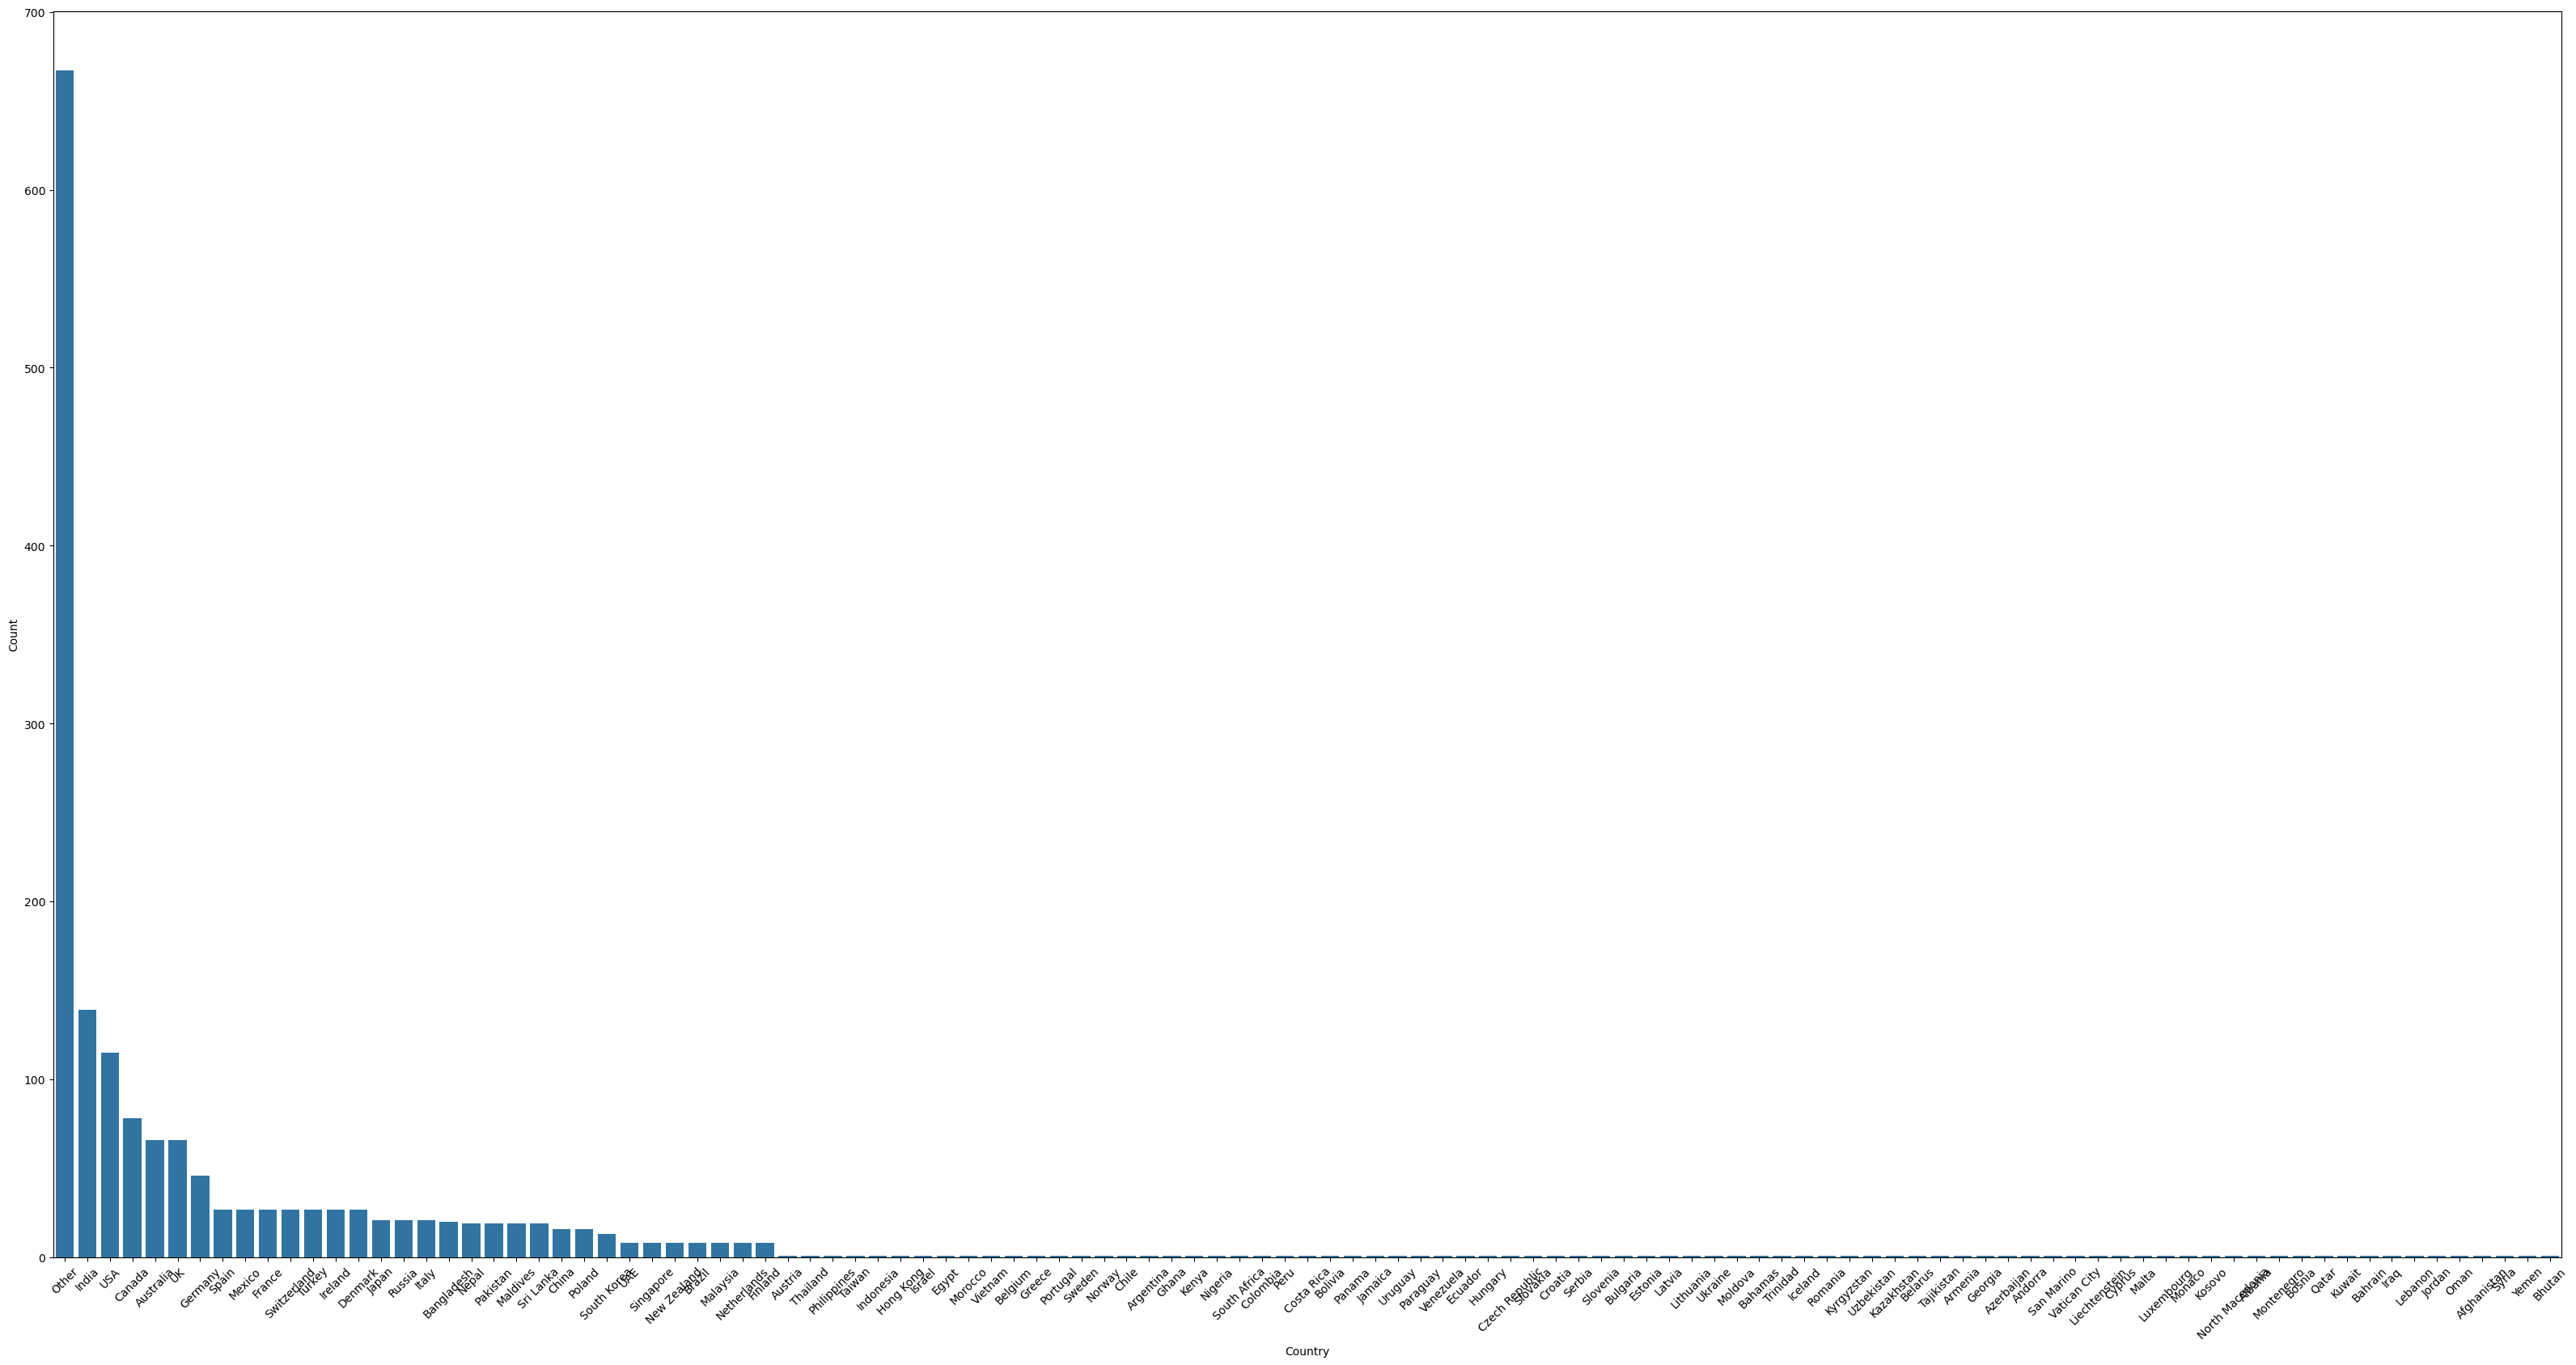

In [18]:
country_counts = data['Country'].value_counts().reset_index()
country_counts.columns = ['Country', 'Count']

sns.barplot(data=country_counts, x='Country', y='Count')
plt.xticks(rotation=45)
plt.show()

### Insight 
- The analysis shows that a large proportion of users belong to the “Other” category, indicating that many participants are from countries not explicitly listed in the dataset.


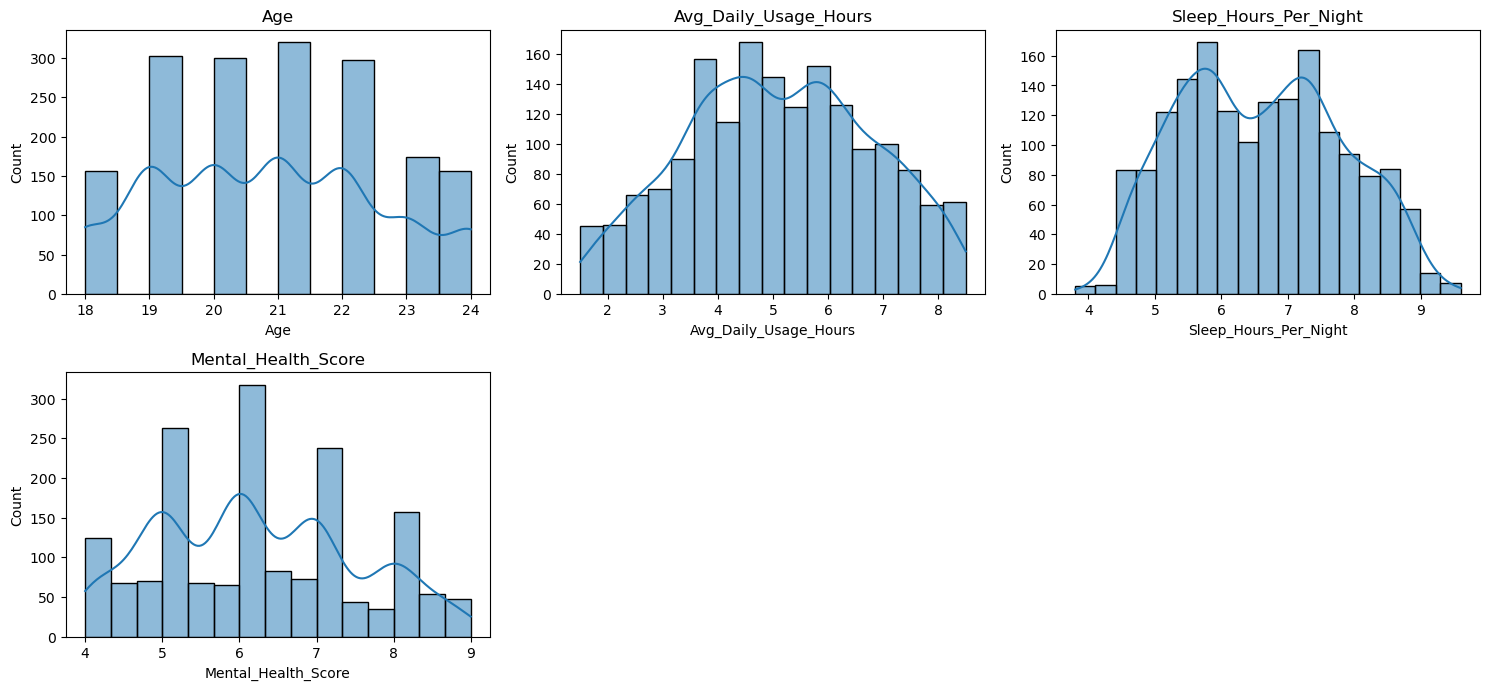

In [19]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.histplot(data[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

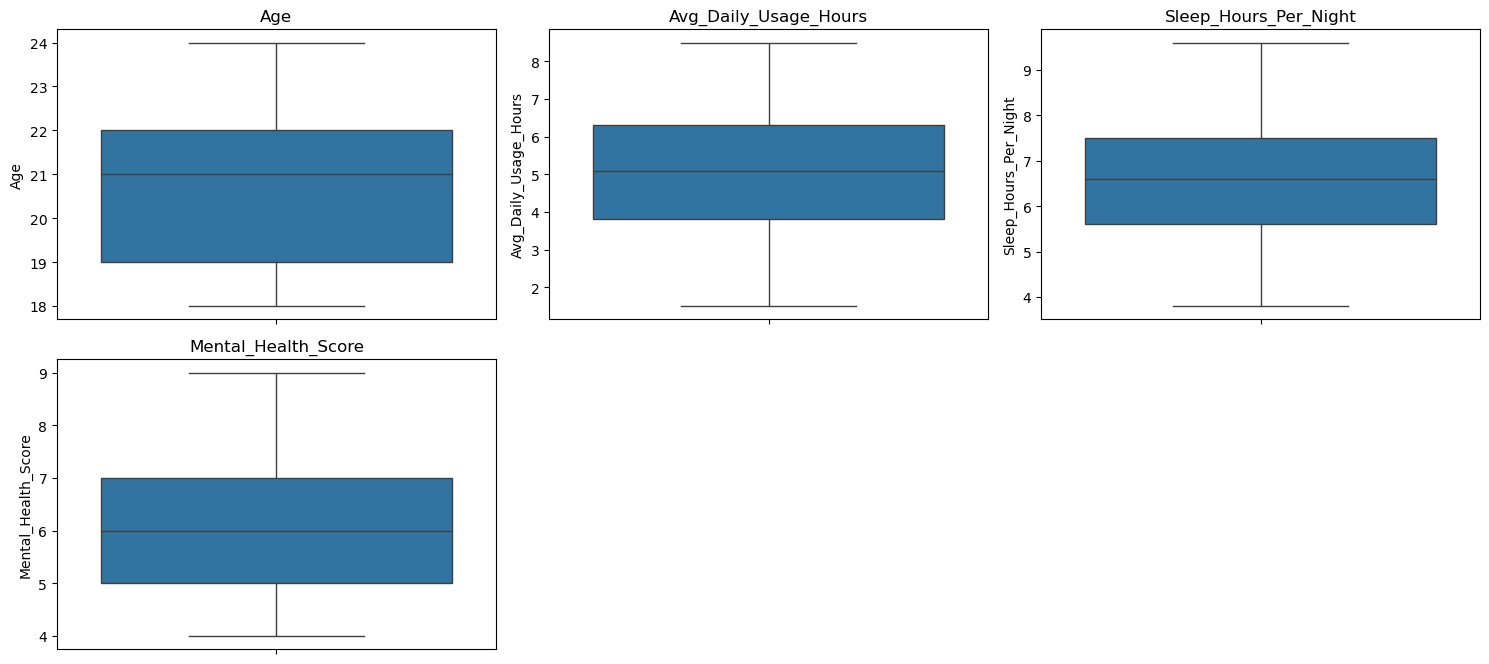

In [20]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1) 
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

### Insights
- There are no outilers in the data

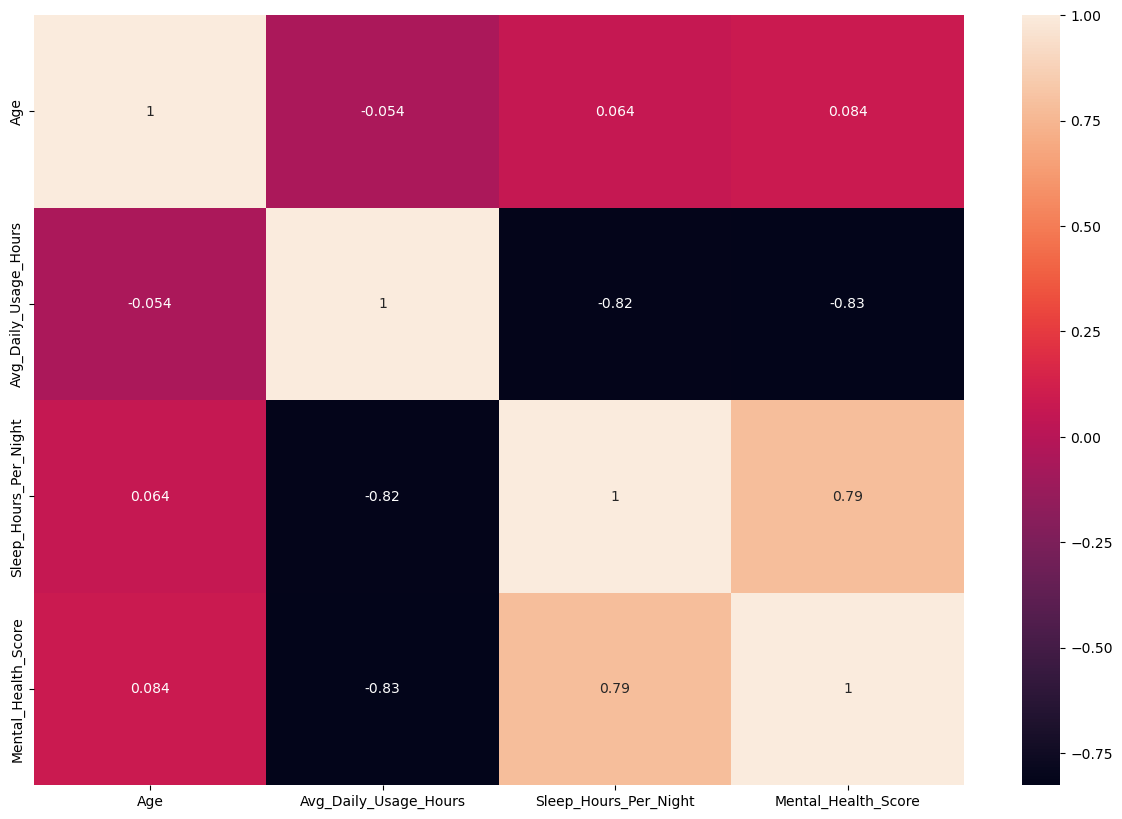

In [21]:
plt.figure(figsize=(15, 10))
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.show()

### Insight
- From the analysis, it is observed that as sleep hours increase, the mental health score also improves. Conversely, reduced sleep hours and higher daily social media usage are associated with lower mental health scores.


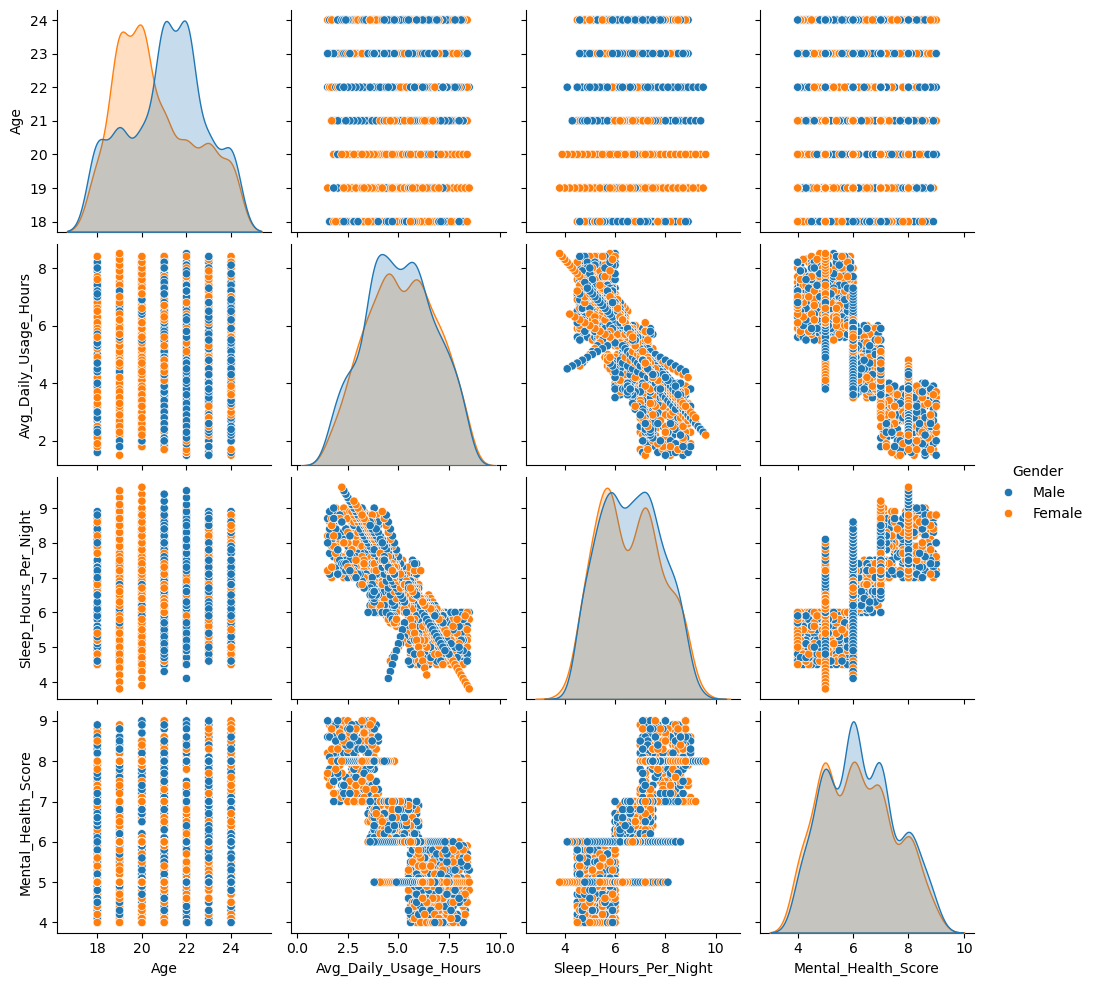

In [22]:
sns.pairplot(data,hue = 'Gender')
plt.show()


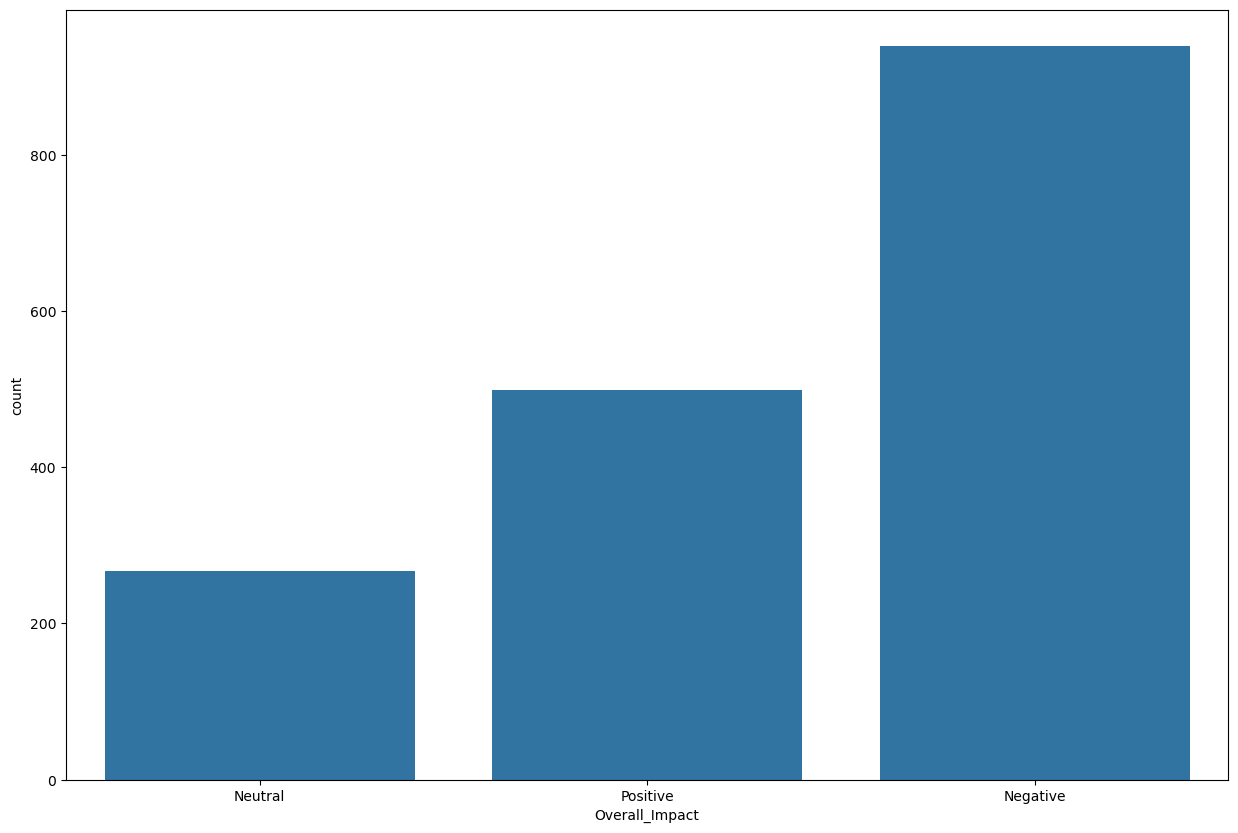

In [26]:
plt.figure(figsize=(15, 10))
sns.countplot(data=data,x='Overall_Impact')
plt.show()

In [27]:
data['Overall_Impact'].value_counts(normalize=True)

Overall_Impact
Negative    0.550733
Positive    0.292669
Neutral     0.156598
Name: proportion, dtype: float64

### Insight 
- The dataset is imbalanced, with the negative class dominating, which may lead to biased model predictions and requires handling using techniques like SMOTE or class weighting.


In [23]:
'''from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Random Forest": RandomForestRegressor(),
    "XGBoost": XGBRegressor(),
}

params = {
    "Linear Regression": {},
    
    "Ridge": {
        "model__alpha": [0.1, 1.0, 10.0]
    },
    
    "Random Forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 10, 20]
    },
    
    "XGBoost": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.01, 0.1],
        "model__max_depth": [3, 6]
    }
}

model_list = []
r2_list = []

for name, model in models.items():
    
    print(f"🔍 Running {name}")
    
    # Pipeline = Feature Selection + Model
    pipe = Pipeline([
        ("feature_selection", SelectKBest(score_func=f_regression, k=10)),
        ("model", model)
    ])
    
    # Grid Search
    gs = GridSearchCV(
        pipe,
        params[name],
        cv=3,
        scoring='r2',
        n_jobs=-1
    )
    
    gs.fit(X_train, y_train)
    
    best_model = gs.best_estimator_
    
    # Predictions
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)
    
    # Evaluation
    train_mae, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred)
    test_mae, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred)
    
    print("Best Params:", gs.best_params_)
    
    print("Train R2:", train_r2)
    print("Test R2:", test_r2)
    
    model_list.append(name)
    r2_list.append(test_r2)
    
    print("="*50)'''

'from sklearn.pipeline import Pipeline\nfrom sklearn.model_selection import GridSearchCV\nfrom sklearn.feature_selection import SelectKBest, f_regression\nfrom sklearn.linear_model import LinearRegression,Ridge\nfrom sklearn.ensemble import RandomForestRegressor\n\nmodels = {\n    "Linear Regression": LinearRegression(),\n    "Ridge": Ridge(),\n    "Random Forest": RandomForestRegressor(),\n    "XGBoost": XGBRegressor(),\n}\n\nparams = {\n    "Linear Regression": {},\n    \n    "Ridge": {\n        "model__alpha": [0.1, 1.0, 10.0]\n    },\n    \n    "Random Forest": {\n        "model__n_estimators": [100, 200],\n        "model__max_depth": [None, 10, 20]\n    },\n    \n    "XGBoost": {\n        "model__n_estimators": [100, 200],\n        "model__learning_rate": [0.01, 0.1],\n        "model__max_depth": [3, 6]\n    }\n}\n\nmodel_list = []\nr2_list = []\n\nfor name, model in models.items():\n    \n    print(f"🔍 Running {name}")\n    \n    # Pipeline = Feature Selection + Model\n    pipe =